In [ ]:
# Step 2: ML Model Training and Evaluation

## Install dependencies
!pip install scikit-learn matplotlib

In [1]:
## Load prepared data
import pickle

# Load training (SMOTE) data
with open("X_train_res.pkl", "rb") as f:
    X_train = pickle.load(f)
with open("y_train_res.pkl", "rb") as f:
    y_train = pickle.load(f)

# Load test data
with open("X_test.pkl", "rb") as f:
    X_test = pickle.load(f)
with open("y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

In [2]:
# Train & Evaluate Multiple Models (RF, SVM, XGBoost, Logistic Regression)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Dictionary of models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
    "SVM": SVC(probability=True, kernel='linear', class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', scale_pos_weight=None, random_state=42
    )
}



 Training Random Forest...
 Random Forest Accuracy: 0.9043
 Random Forest AUC: 0.9231
              precision    recall  f1-score   support

           0       0.78      0.59      0.67       133
           1       0.92      0.97      0.94       672

    accuracy                           0.90       805
   macro avg       0.85      0.78      0.81       805
weighted avg       0.90      0.90      0.90       805



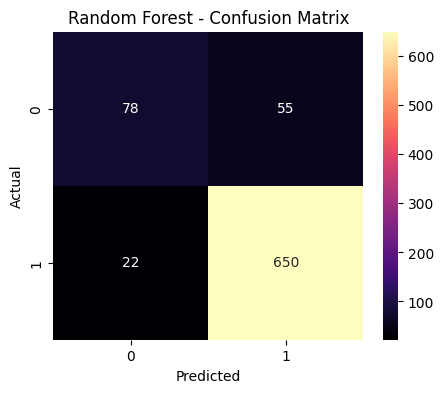


 Training SVM...
 SVM Accuracy: 0.8820
 SVM AUC: 0.8707
              precision    recall  f1-score   support

           0       0.67      0.57      0.62       133
           1       0.92      0.94      0.93       672

    accuracy                           0.88       805
   macro avg       0.79      0.76      0.77       805
weighted avg       0.88      0.88      0.88       805



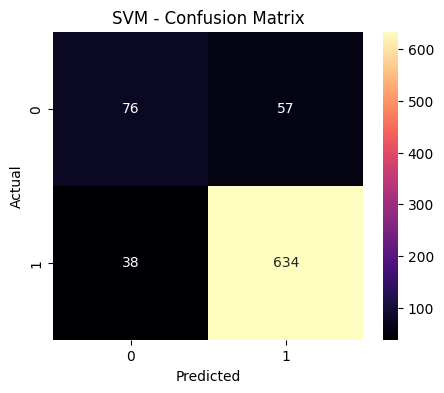


 Training Logistic Regression...
 Logistic Regression Accuracy: 0.8907
 Logistic Regression AUC: 0.8901
              precision    recall  f1-score   support

           0       0.72      0.55      0.62       133
           1       0.91      0.96      0.94       672

    accuracy                           0.89       805
   macro avg       0.82      0.75      0.78       805
weighted avg       0.88      0.89      0.88       805



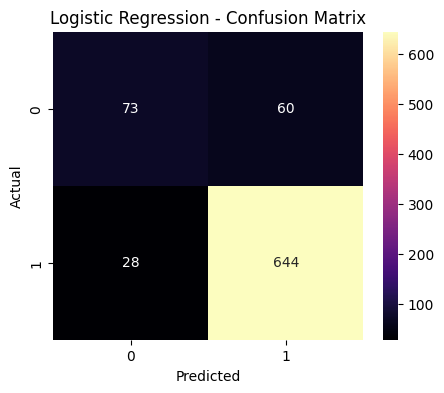


 Training XGBoost...
 XGBoost Accuracy: 0.9006
 XGBoost AUC: 0.9003
              precision    recall  f1-score   support

           0       0.75      0.60      0.67       133
           1       0.92      0.96      0.94       672

    accuracy                           0.90       805
   macro avg       0.84      0.78      0.80       805
weighted avg       0.89      0.90      0.90       805



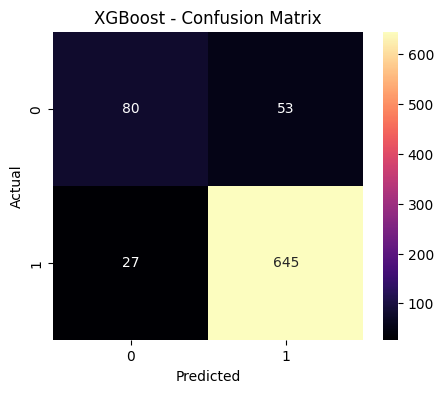

In [5]:
results = {}

# Loop over models
for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "AUC": auc, "Report": report, "CM": cm}

    # Print results
    print(f" {name} Accuracy: {acc:.4f}")
    print(f" {name} AUC: {auc:.4f}")
    print(report)

    # Confusion Matrix Heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="magma", cbar=True)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [6]:
# Summary of Accuracy & AUC

print("\n Summary of Model Performance:\n")
for name, metrics in results.items():
    print(f"{name}: Accuracy={metrics['Accuracy']:.4f}, AUC={metrics['AUC']:.4f}")


 Summary of Model Performance:

Random Forest: Accuracy=0.9043, AUC=0.9231
SVM: Accuracy=0.8820, AUC=0.8707
Logistic Regression: Accuracy=0.8907, AUC=0.8901
XGBoost: Accuracy=0.9006, AUC=0.9003


In [7]:
## Since RF and XGB worked good and RF is selected as BEST MODEL and saved this trained model

model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [8]:
# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [9]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9043478260869565
AUC Score: 0.9230721894020767
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.59      0.67       133
           1       0.92      0.97      0.94       672

    accuracy                           0.90       805
   macro avg       0.85      0.78      0.81       805
weighted avg       0.90      0.90      0.90       805



In [10]:
## roc curve
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go

In [11]:
roc_data = {}

for name, model in models.items():
    # Predict probabilities for positive class (Active = 1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    roc_data[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc
    }

In [12]:
fig = go.Figure()

# Add ROC curve for each model
for name, data in roc_data.items():
    fig.add_trace(go.Scatter(
        x=data["fpr"],
        y=data["tpr"],
        mode="lines",
        name=f"{name} (AUC = {data['auc']:.3f})"
    ))

# Add diagonal (random classifier)
fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode="lines",
    line=dict(dash="dash"),
    name="Random Classifier"
))

# Layout settings
fig.update_layout(
    title="ROC Curve Comparison for All Models<br><sup>1 = Active compounds, 0 = Inactive compounds</sup>",
    xaxis_title="False Positive Rate (Inactive predicted as Active)",
    yaxis_title="True Positive Rate (Correctly predicted Active)",
    width=800,
    height=600,
    legend=dict(x=0.6, y=0.05),
    template="plotly_white"
)

fig.show()

In [13]:
# Save your trained model

import joblib
joblib.dump(model, "rf_model.pkl")
print(" Model saved as rf_model.pkl")

 Model saved as rf_model.pkl
